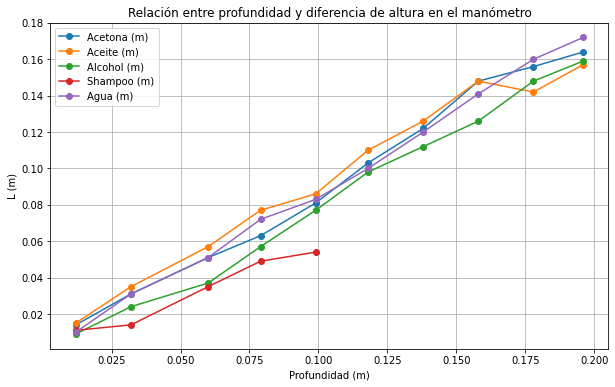

       Profundidades (m)  Acetona (m)  Aceite (m)  Alcohol (m)  Shampoo (m)  \
count          10.000000    10.000000   10.000000    10.000000     5.000000   
mean            0.107000     0.093300    0.095300     0.084700     0.032600   
std             0.061781     0.053612    0.049324     0.052358     0.019655   
min             0.012000     0.014000    0.015000     0.009000     0.011000   
25%             0.064750     0.054000    0.062000     0.042000     0.014000   
50%             0.108500     0.092000    0.098000     0.087500     0.035000   
75%             0.153000     0.141500    0.138000     0.122500     0.049000   
max             0.196000     0.164000    0.157000     0.159000     0.054000   

       Agua (m)  
count  10.00000  
mean    0.09400  
std     0.05461  
min     0.01000  
25%     0.05625  
50%     0.09150  
75%     0.13575  
max     0.17200  


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Datos de la tabla
profundidades = [
    0.0120, 0.0320, 0.0600, 0.0790, 0.0990, 
    0.1180, 0.1380, 0.1580, 0.1780, 0.1960
]

acetonas = [0.0140, 0.0310, 0.0510, 0.0630, 0.0810, 0.1030, 0.1220, 0.1480, 0.1560, 0.1640]
aceites = [0.0150, 0.0350, 0.0570, 0.0770, 0.0860, 0.1100, 0.1260, 0.1480, 0.1420, 0.1570]
alcoholes = [0.0090, 0.0240, 0.0370, 0.0570, 0.0770, 0.0980, 0.1120, 0.1260, 0.1480, 0.1590]
shampoos = [0.0110, 0.0140, 0.0350, 0.0490, 0.0540, None, None, None, None, None]
aguas = [0.0100, 0.0310, 0.0510, 0.0720, 0.0830, 0.1000, 0.1200, 0.1410, 0.1600, 0.1720]

# Crear DataFrame
data = {
    "Profundidades (m)": profundidades,
    "Acetona (m)": acetonas,
    "Aceite (m)": aceites,
    "Alcohol (m)": alcoholes,
    "Shampoo (m)": shampoos,
    "Agua (m)": aguas
}

df = pd.DataFrame(data)

# Calcular estadísticas básicas
stats = df.describe()

# Graficar los datos
plt.figure(figsize=(10, 6))
for liquido in ["Acetona (m)", "Aceite (m)", "Alcohol (m)", "Shampoo (m)", "Agua (m)"]:
    plt.plot(df["Profundidades (m)"], df[liquido], marker='o', label=liquido)

plt.xlabel("Profundidad (m)")
plt.ylabel("L (m)")
plt.title("Relación entre profundidad y diferencia de altura en el manómetro")
plt.legend()
plt.grid()
plt.show()

# Guardar estadísticas en un archivo
stats.to_csv("estadisticas_liquidos.csv")

# Mostrar estadísticas
print(stats)


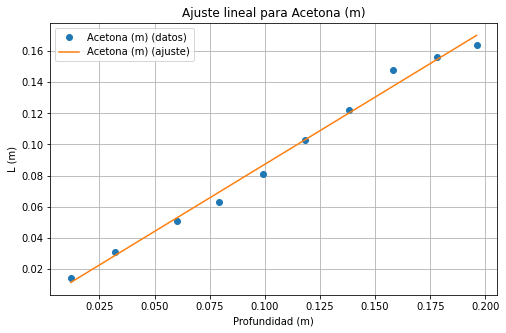


Acetona (m):
  Pendiente: 0.8637342803912437
  Intercepto: 0.0008804319981369491
  R-cuadrado: 0.9907128793181017


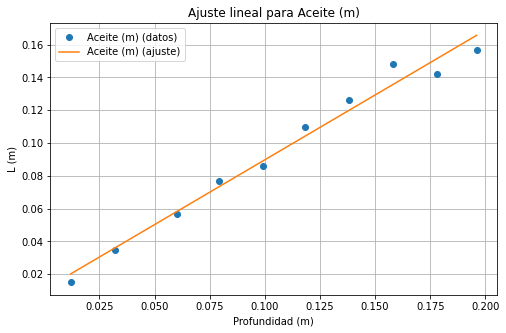


Aceite (m):
  Pendiente: 0.7902305542617606
  Intercepto: 0.01074533069399164
  R-cuadrado: 0.9796995184525901


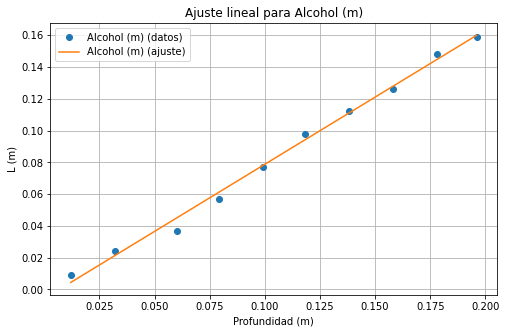


Alcohol (m):
  Pendiente: 0.8450454122030743
  Intercepto: -0.005719859105728919
  R-cuadrado: 0.9942738263399972


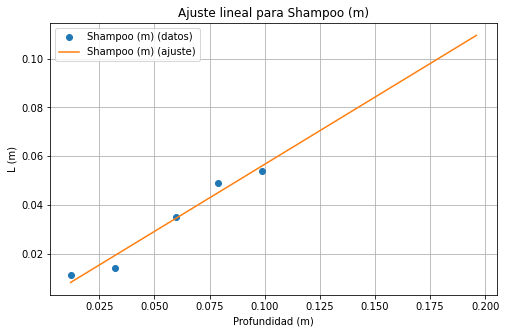


Shampoo (m):
  Pendiente: 0.5512109597977655
  Intercepto: 0.0015117018674060297
  R-cuadrado: 0.9645121622451456


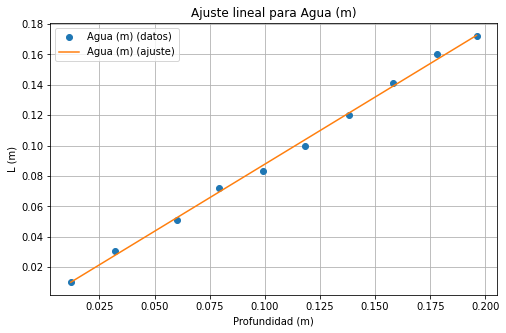


Agua (m):
  Pendiente: 0.8828306939916161
  Intercepto: -0.00046288425710290515
  R-cuadrado: 0.9975263210388876


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Datos de la tabla
profundidades = [
    0.0120, 0.0320, 0.0600, 0.0790, 0.0990, 
    0.1180, 0.1380, 0.1580, 0.1780, 0.1960
]

acetonas = [0.0140, 0.0310, 0.0510, 0.0630, 0.0810, 0.1030, 0.1220, 0.1480, 0.1560, 0.1640]
aceites = [0.0150, 0.0350, 0.0570, 0.0770, 0.0860, 0.1100, 0.1260, 0.1480, 0.1420, 0.1570]
alcoholes = [0.0090, 0.0240, 0.0370, 0.0570, 0.0770, 0.0980, 0.1120, 0.1260, 0.1480, 0.1590]
shampoos = [0.0110, 0.0140, 0.0350, 0.0490, 0.0540, None, None, None, None, None]
aguas = [0.0100, 0.0310, 0.0510, 0.0720, 0.0830, 0.1000, 0.1200, 0.1410, 0.1600, 0.1720]

# Crear DataFrame
data = {
    "Profundidades (m)": profundidades,
    "Acetona (m)": acetonas,
    "Aceite (m)": aceites,
    "Alcohol (m)": alcoholes,
    "Shampoo (m)": shampoos,
    "Agua (m)": aguas
}

df = pd.DataFrame(data)

# Ajuste lineal y gráficos individuales para cada líquido
for liquido in ["Acetona (m)", "Aceite (m)", "Alcohol (m)", "Shampoo (m)", "Agua (m)"]:
    x = df["Profundidades (m)"].values
    y = df[liquido].dropna().values  # Eliminar valores NaN
    slope, intercept, r_value, p_value, std_err = linregress(x[:len(y)], y)

    # Graficar datos y ajuste lineal
    plt.figure(figsize=(8, 5))
    plt.plot(x[:len(y)], y, 'o', label=f"{liquido} (datos)")
    plt.plot(x, slope * x + intercept, '-', label=f"{liquido} (ajuste)")
    plt.xlabel("Profundidad (m)")
    plt.ylabel("L (m)")
    plt.title(f"Ajuste lineal para {liquido}")
    plt.legend()
    plt.grid()
    plt.show()

    # Imprimir parámetros del ajuste
    print(f"\n{liquido}:")
    print(f"  Pendiente: {slope}")
    print(f"  Intercepto: {intercept}")
    print(f"  R-cuadrado: {r_value**2}")